In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from math import sqrt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.neural_network import MLPClassifier

In [ ]:
!pip install ipython-autotime
%load_ext autotime

time: 148 µs


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
time: 22.7 s


Preprocessing of the dataset

In [ ]:
data = pd.read_csv("drive/MyDrive/Taiwan Hospice Project/PrimaryDiagnosisAdded.csv")

time: 16.5 s


In [ ]:
#Organize the data:
for i in range(1,46):
  if(i<10):
    name = 'HP0'+ str(i)
  else:
    name = 'HP'+ str(i)
  data.loc[data.PATIENT == name, 'dead'] = 0

time: 8.7 s


In [ ]:
dead_patients= ['06','07','08','11','12','14','17','20','21','22','23','25','29','32','35','37','40','42','45']
for i in dead_patients:
  name = 'HP'+i
  data.loc[data.PATIENT == name, 'dead'] = 1

time: 3.66 s


In [ ]:
data

,ACT,Angle,Spin,PATIENT,DateTime,dead
0,168.00,3.0,12.0,HP01,2019-09-03 10:05:17,0.0
1,191.00,4.0,11.0,HP01,2019-09-03 10:05:27,0.0
2,211.00,3.0,0.0,HP01,2019-09-03 10:05:37,0.0
3,87.00,2.0,3.0,HP01,2019-09-03 10:05:47,0.0
4,7.19,3.0,1.0,HP01,2019-09-03 10:05:57,0.0
...,...,...,...,...,...,...
2939766,1.81,15.0,0.0,HP45,2020-08-19 20:18:38,1.0
2939767,1.75,15.0,0.0,HP45,2020-08-19 20:18:48,1.0
2939768,1.56,15.0,0.0,HP45,2020-08-19 20:18:58,1.0
2939769,1.62,15.0,0.0,HP45,2020-08-19 20:19:08,1.0


time: 27.1 ms


In [ ]:
data = data[['ACT', 'Angle', 'Spin', 'PATIENT', 'DateTime', 'dead']]

time: 90.7 ms


In [ ]:
data.loc[data.PATIENT == 'HP01', 'Time'] = 19   
data.loc[data.PATIENT == 'HP02', 'Time'] = 9
data.loc[data.PATIENT == 'HP03', 'Time'] = 4
data.loc[data.PATIENT == 'HP04', 'Time'] = 2
data.loc[data.PATIENT == 'HP05', 'Time'] = 11
data.loc[data.PATIENT == 'HP06', 'Time'] = 2
data.loc[data.PATIENT == 'HP07', 'Time'] = 4
data.loc[data.PATIENT == 'HP08', 'Time'] = 3
data.loc[data.PATIENT == 'HP09', 'Time'] = 2
data.loc[data.PATIENT == 'HP10', 'Time'] = 5
data.loc[data.PATIENT == 'HP11', 'Time'] = 11
data.loc[data.PATIENT == 'HP13', 'Time'] = 4
data.loc[data.PATIENT == 'HP14', 'Time'] = 14
data.loc[data.PATIENT == 'HP15', 'Time'] = 3
data.loc[data.PATIENT == 'HP16', 'Time'] = 23
data.loc[data.PATIENT == 'HP18', 'Time'] = 13
data.loc[data.PATIENT == 'HP20', 'Time'] = 1
data.loc[data.PATIENT == 'HP21', 'Time'] = 28
data.loc[data.PATIENT == 'HP22', 'Time'] = 24
data.loc[data.PATIENT == 'HP23', 'Time'] = 14
data.loc[data.PATIENT == 'HP24', 'Time'] = 5
data.loc[data.PATIENT == 'HP25', 'Time'] = 5
data.loc[data.PATIENT == 'HP28', 'Time'] = 4
data.loc[data.PATIENT == 'HP29', 'Time'] = 8
data.loc[data.PATIENT == 'HP30', 'Time'] = 17
data.loc[data.PATIENT == 'HP32', 'Time'] = 7
data.loc[data.PATIENT == 'HP33', 'Time'] = 9
data.loc[data.PATIENT == 'HP34', 'Time'] = 8
data.loc[data.PATIENT == 'HP35', 'Time'] = 2
data.loc[data.PATIENT == 'HP36', 'Time'] = 3
data.loc[data.PATIENT == 'HP37', 'Time'] = 5
data.loc[data.PATIENT == 'HP38', 'Time'] = 6
data.loc[data.PATIENT == 'HP39', 'Time'] = 15
data.loc[data.PATIENT == 'HP41', 'Time'] = 17
data.loc[data.PATIENT == 'HP42', 'Time'] = 2
data.loc[data.PATIENT == 'HP43', 'Time'] = 10
data.loc[data.PATIENT == 'HP44', 'Time'] = 9
data.loc[data.PATIENT == 'HP45', 'Time'] = 2

time: 7.52 s


In [ ]:
data = data.dropna(subset=['PATIENT', 'DateTime', 'Time', 'ACT', 'Angle', 'Spin', 'dead'])

time: 708 ms


In [ ]:
data = data[['Time', 'ACT', 'Angle', 'Spin', 'dead']]

time: 75.7 ms


In [ ]:
data

,Time,ACT,Angle,Spin,dead
0,19.0,168.00,3.0,12.0,0.0
1,19.0,191.00,4.0,11.0,0.0
2,19.0,211.00,3.0,0.0,0.0
3,19.0,87.00,2.0,3.0,0.0
4,19.0,7.19,3.0,1.0,0.0
...,...,...,...,...,...
2939766,2.0,1.81,15.0,0.0,1.0
2939767,2.0,1.75,15.0,0.0,1.0
2939768,2.0,1.56,15.0,0.0,1.0
2939769,2.0,1.62,15.0,0.0,1.0


time: 25.7 ms


In [ ]:
data.describe()

,Time,ACT,Angle,Spin,dead
count,2.939771e+06,2.939771e+06,2.939771e+06,2.939771e+06,2.939771e+06
mean,1.394875e+01,1.579544e+01,7.619863e+00,6.856723e+00,4.269873e-01
std,7.538866e+00,4.919403e+01,2.422888e+00,2.884200e+00,4.946405e-01
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.000000e+00,8.013911e+00,7.018926e+00,5.692380e+00,0.000000e+00
50%,1.400000e+01,1.092452e+01,7.327670e+00,6.590279e+00,0.000000e+00
75%,1.900000e+01,1.644000e+01,8.983976e+00,8.264637e+00,1.000000e+00
max,2.800000e+01,6.080000e+03,1.500000e+01,1.500000e+01,1.000000e+00


time: 406 ms


In [ ]:
del data[['PATIENT']

KeyError: ignored

time: 38.2 ms


In [ ]:
del data['DateTime']

time: 73.4 ms


Defining Our Model

In [ ]:
X = data.drop(["Time"], axis=1)

time: 349 ms


In [ ]:
y = data["Time"]

time: 779 µs


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

time: 3.13 s


In [ ]:
X_train.shape

(2351816, 59)

time: 3.78 ms


In [ ]:



X_test.shape

(587955, 59)

time: 3.38 ms


Standardisation of the defined model

In [ ]:


scaler = StandardScaler()

time: 1.27 ms


In [ ]:
train_scaled = scaler.fit_transform(X_train)

time: 3.32 s


In [ ]:


test_scaled = scaler.transform(X_test)

time: 264 ms





1. a. Linear Regression Model

In [ ]:





model = LinearRegression()

time: 876 µs


In [ ]:
model.fit(train_scaled, y_train)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

time: 11.9 s


In [ ]:
mse = mean_squared_error(y_train, model.predict(train_scaled))
mae = mean_absolute_error(y_train, model.predict(train_scaled))

time: 447 ms


In [ ]:
print("mse = ",mse," & mae = ",mae," & rmse = ", sqrt(mse))

mse =  0.29173230430367436  & mae =  0.10672648586346359  & rmse =  0.5401224900924552
time: 4 ms


In [ ]:
test_mse = mean_squared_error(y_test, model.predict(test_scaled))
test_mae = mean_absolute_error(y_test, model.predict(test_scaled))
print("mse = ",test_mse," & mae = ",test_mae," & rmse = ", sqrt(test_mse))

mse =  0.2932432459648565  & mae =  0.10686042485742848  & rmse =  0.5415193865087902
time: 124 ms


In [ ]:
model.predict([test_scaled[0]])

array([27.92966234])

time: 8.78 ms


In [ ]:
X_test

,ACT,Angle,Spin,dead,kf_score,Adenocarcinoma of Ascending Colon,Bone Metastatis,Brain Metastatis,Carcinoma in situ 3 of Cervix,Diffuse Liver Metastatis,EV Bleeding,Intra-abdominal seedings,Left Malignant Pleural Metastatis,Left Retromolar Cancer,Left Tongue Cancer,Liver Metastatis,Lower Limbs Paralysis,Lung Metastatis,Lymph Node Metastatis,Lymph nodes and Colon Invasion,Malignant Ascites,Mesenteric Seeding,Multiple Bone Metastatis,Multiple Peritoneal Tumor Seedings,Peritoneal Seeding,Right Breast Cancer,Right Lower Lung Non-Small Cell Carcinoma,Right Posterior Tongue Cancer,Spine Metastatis,Stage IV,Ampullavater Adenocarcinoma,Bladder Urothelial Carcinoma,Breat Cancer,Cervical Cancer,Colon Cancer,GBM Grade 4,Gastric Cancer,Gastric Poorly Differentiated Adenocarcinoma,Gastric Poorly Differentiatied Adenocarcinoma,HCC,Hepatocellular Carcinoma,High Grade Glioma at pons,Left Buccal Squamous Cell Carcinoma,Left Upper Lobe Adenocarcinoma,Lower Third Esophageal Squamous Cell Carcinoma,Lung Adenocarcinoma,Lung Cancer,Lung Squamous Cell Carcinoma,None,Ovarian Cancer,Ovarian Cancer Adenocarcinoma,Prostate Cancer,Rectal Adenocarcinoma,Rectal Cancer,Right Breast Cancer,Sigmoid Adenocarcinoma,Sigmoid Colon Adenocarcinoma,Sigmoid Colon Cancer,Vaginal Cancer
1264109,2.750000,10.000000,15.000000,1.0,30.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1893775,0.000000,0.000000,0.000000,0.0,30.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1554922,0.000000,0.000000,0.000000,1.0,50.0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
363461,16.235704,5.830524,5.029713,0.0,60.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
1546746,4.880000,9.000000,1.000000,1.0,50.0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2615223,2.103377,2.960752,1.817145,0.0,40.0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
851633,2.810000,1.000000,15.000000,0.0,50.0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1041589,0.000000,0.000000,0.000000,0.0,60.0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
176342,295.000000,0.000000,12.000000,0.0,50.0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


time: 132 ms


1. b. Learning Curve plot of the Linear Regression Model

In [ ]:
train_sizes = [1, 100, 500, 2000, 5000, 7654]

time: 982 µs


In [ ]:
from sklearn.model_selection import learning_curve

time: 735 µs


In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(
estimator = LinearRegression(),
X = X_train,
y = y_train, train_sizes = train_sizes, cv = 5,
scoring = 'neg_mean_squared_error')

time: 7.42 s


In [ ]:
train_scores_mean = -train_scores.mean(axis = 1)
validation_scores_mean = -validation_scores.mean(axis = 1)

time: 1.66 ms


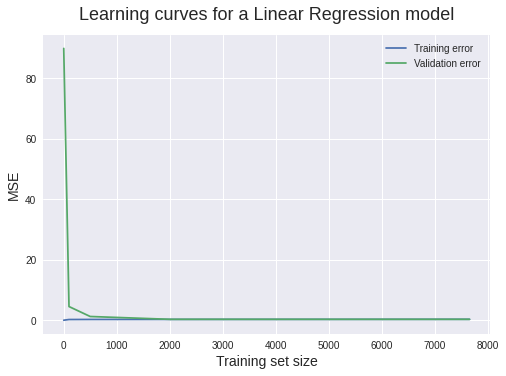

time: 253 ms


In [ ]:
plt.style.use('seaborn')
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for a Linear Regression model', fontsize = 18, y = 1.03)
plt.legend()
#plt.ylim(100,100)

2. a. Decision Tree Regression Model  
3. a. Random Forest Regression Model

In [ ]:
tree_model = DecisionTreeRegressor()
rf_model = RandomForestRegressor()

time: 7.76 ms


In [ ]:
tree_model.fit(train_scaled, y_train)
rf_model.fit(train_scaled, y_train)

RandomForestRegressor(bootstrap=True, ccp_alpha=0.0, criterion='mse',
                      max_depth=None, max_features='auto', max_leaf_nodes=None,
                      max_samples=None, min_impurity_decrease=0.0,
                      min_impurity_split=None, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      n_estimators=100, n_jobs=None, oob_score=False,
                      random_state=None, verbose=0, warm_start=False)

time: 18min 24s


In [ ]:
tree_mse = mean_squared_error(y_train, tree_model.predict(train_scaled))
tree_mae = mean_absolute_error(y_train, tree_model.predict(train_scaled))
rf_mse = mean_squared_error(y_train, rf_model.predict(train_scaled))
rf_mae = mean_absolute_error(y_train, rf_model.predict(train_scaled))

time: 41 s


In [ ]:
print("Decision Tree training mse = ",tree_mse," & mae = ",tree_mae," & rmse = ", sqrt(tree_mse))
print("Random Forest training mse = ",rf_mse," & mae = ",rf_mae," & rmse = ", sqrt(rf_mse))

Decision Tree training mse =  0.10264895611219098  & mae =  0.029328273174911698  & rmse =  0.3203887577805922
Random Forest training mse =  0.10812254797300136  & mae =  0.03272000972578515  & rmse =  0.32881993244479774
time: 4.63 ms


In [ ]:
tree_test_mse = mean_squared_error(y_test, tree_model.predict(test_scaled))
tree_test_mae = mean_absolute_error(y_test, tree_model.predict(test_scaled))
rf_test_mse = mean_squared_error(y_test, rf_model.predict(test_scaled))
rf_test_mae = mean_absolute_error(y_test, rf_model.predict(test_scaled))

time: 11 s


In [ ]:
print("Decision Tree test mse = ",tree_test_mse," & mae = ",tree_test_mae," & rmse = ", sqrt(tree_test_mse))
print("Random Forest test mse = ",rf_test_mse," & mae = ",rf_test_mae," & rmse = ", sqrt(rf_test_mse))

Decision Tree test mse =  0.17534472410065263  & mae =  0.03910237503930311  & rmse =  0.41874183466743875
Random Forest test mse =  0.15271328673533055  & mae =  0.03956254551762768  & rmse =  0.39078547405876096
time: 2.1 ms


2. b. Learning Curve plot of the Decision Tree Regression Model

In [ ]:
train_sizes = [1, 100, 500, 2000, 5000, 7654]

time: 833 µs


In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(
estimator = DecisionTreeRegressor(),
X = train_scaled,
y = y_train, train_sizes = train_sizes, cv = 5,
scoring = 'neg_mean_squared_error')

time: 6.51 s


In [ ]:
train_scores_mean = -train_scores.mean(axis = 1)
validation_scores_mean = -validation_scores.mean(axis = 1)

time: 2.69 ms


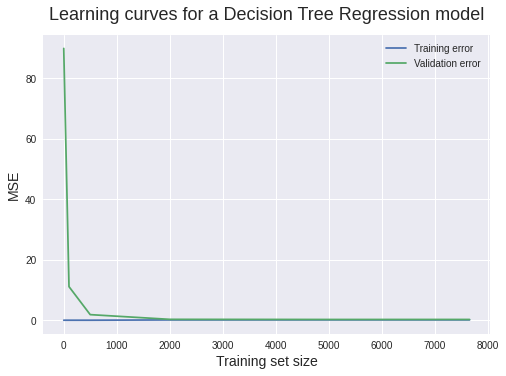

time: 242 ms


In [ ]:
plt.style.use('seaborn')
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for a Decision Tree Regression model', fontsize = 18, y = 1.03)
plt.legend()
#plt.ylim(100,100)

3. b. Learning Curve plot of the Random Forest Regression Model

In [ ]:
train_sizes = [1, 100, 500, 2000, 5000, 7654]

time: 1.19 ms


In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(
estimator = RandomForestRegressor(),
X = train_scaled,
y = y_train, train_sizes = train_sizes, cv = 5,
scoring = 'neg_mean_squared_error')

time: 1min 40s


In [ ]:
train_scores_mean = -train_scores.mean(axis = 1)
validation_scores_mean = -validation_scores.mean(axis = 1)

time: 1.69 ms


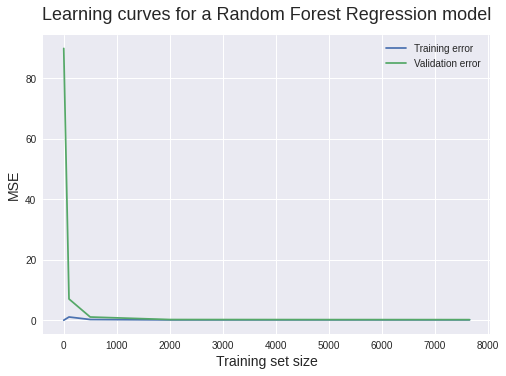

time: 241 ms


In [ ]:
plt.style.use('seaborn')
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for a Random Forest Regression model', fontsize = 18, y = 1.03)
plt.legend()
#plt.ylim(100,100)

4. a. Gradient Boosting Classifier Model

In [ ]:
y_train=y_train.astype('int')

time: 14.3 ms


In [ ]:
y_test=y_test.astype('int')

time: 4.16 ms


In [ ]:
clf = GradientBoostingClassifier(random_state=0)

time: 1.17 ms


In [ ]:
clf.fit(train_scaled, y_train)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='deviance', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_impurity_split=None,
                           min_samples_leaf=1, min_samples_split=2,
                           min_weight_fraction_leaf=0.0, n_estimators=100,
                           n_iter_no_change=None, presort='deprecated',
                           random_state=0, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)

time: 2h 5min 6s


In [ ]:
clf.predict(test_scaled)

array([28, 17, 24, ..., 13,  9,  2])

time: 27.9 s


In [ ]:
clf.score(test_scaled, y_test)

0.995758178772185

time: 27.6 s


In [ ]:
clf.predict(train_scaled)

array([19,  5, 14, ..., 19,  2, 23])

time: 1min 51s


In [ ]:
clf.score(train_scaled, y_train)

0.9958423618174211

time: 1min 48s


4. b. Learning Curve plot for Gradient Boosting Classifier Model

In [ ]:
train_sizes = [1, 100, 500, 2000, 5000, 7654]

time: 1.48 ms


In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(
estimator = GradientBoostingClassifier(random_state=0),
X = X_train,
y = y_train, train_sizes = train_sizes, cv = 5,
scoring = 'neg_mean_squared_error')

/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: y contains 1 class after sample_weight trimmed classes with zero weights, while a minimum of 2 classes are required.

  FitFailedWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: y contains 1 class after sample_weight trimmed classes with zero weights, while a minimum of 2 classes are required.

  FitFailedWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: y contains 1 class after sample_weight trimmed cl

time: 11min 2s


In [ ]:
train_scores_mean = -train_scores.mean(axis = 1)
validation_scores_mean = -validation_scores.mean(axis = 1)

time: 2.11 ms


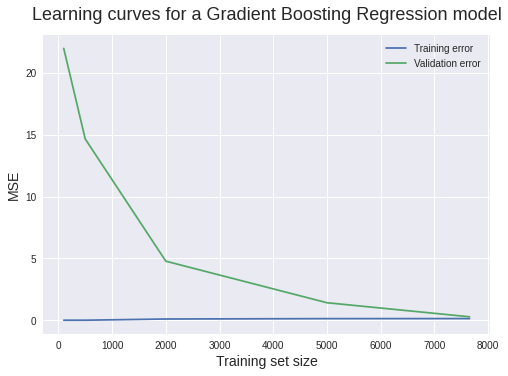

time: 243 ms


In [ ]:
plt.style.use('seaborn')
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for a Gradient Boosting Regression model', fontsize = 18, y = 1.03)
plt.legend()
#plt.ylim(100,100)

5. a. Logistic Regression Model

In [ ]:
logreg = LogisticRegression()
logreg.fit(train_scaled, y_train)

/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

time: 7min 17s


In [ ]:
y_pred = logreg.predict(train_scaled)
print('Accuracy of logistic regression classifier on train set: {:.2f}'.format(logreg.score(test_scaled, y_test)))

Accuracy of logistic regression classifier on train set: 0.99
time: 1.51 s


In [ ]:
y_pred = logreg.predict(test_scaled)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(test_scaled, y_test)))

Accuracy of logistic regression classifier on test set: 0.99
time: 579 ms


5. b. Learning Curve plot of Logisitic Regression Model

In [ ]:
train_sizes = [1, 100, 500, 2000, 5000, 7654]

time: 1.14 ms


In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(
estimator = LogisticRegression(),
X = X_train,
y = y_train, train_sizes = train_sizes, cv = 5,
scoring = 'neg_mean_squared_error')

/usr/local/lib/python3.6/dist-packages/sklearn/model_selection/_validation.py:536: FitFailedWarning: Estimator fit failed. The score on this train-test partition for these parameters will be set to nan. Details: 
ValueError: This solver needs samples of at least 2 classes in the data, but the data contains only one class: 1

  FitFailedWarning)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
/usr/local/lib/python3.6/dist-packages/sklearn/linear_model/_logistic.py:940: ConvergenceWarning: lbfgs failed to converge (st

time: 32.3 s


In [ ]:
train_scores_mean = -train_scores.mean(axis = 1)
validation_scores_mean = -validation_scores.mean(axis = 1)

time: 1.68 ms


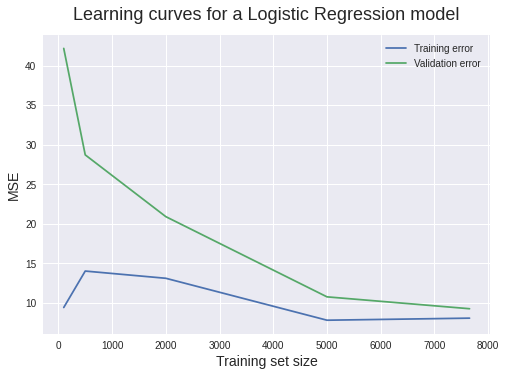

time: 254 ms


In [ ]:
plt.style.use('seaborn')
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for a Logistic Regression model', fontsize = 18, y = 1.03)
plt.legend()
#plt.ylim(100,100)

6. a. Multi-Layer Perceptron Classifier Neural Network Model

In [ ]:
mlp = MLPClassifier(hidden_layer_sizes=(250,200,150), activation='relu', solver='adam', max_iter=15)
mlp.fit(train_scaled,y_train)

predict_train = mlp.predict(train_scaled)
predict_test = mlp.predict(test_scaled)

/usr/local/lib/python3.6/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (15) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_train,predict_train))
print(classification_report(y_train,predict_train))

In [ ]:
print(confusion_matrix(y_test,predict_test))
print(classification_report(y_test,predict_test))

6. b. Learning Curve plot for Multi-Layer Perceptron Classifier Model

In [ ]:
train_sizes = [1, 100, 500, 2000, 5000, 7654]

In [ ]:
train_sizes, train_scores, validation_scores = learning_curve(
estimator = MLPClassifier(hidden_layer_sizes=(250,200,150), activation='relu', solver='adam', max_iter=15),
X = X_train,
y = y_train, train_sizes = train_sizes, cv = 5,
scoring = 'neg_mean_squared_error')

In [ ]:
train_scores_mean = -train_scores.mean(axis = 1)
validation_scores_mean = -validation_scores.mean(axis = 1)

In [ ]:
plt.style.use('seaborn')
plt.plot(train_sizes, train_scores_mean, label = 'Training error')
plt.plot(train_sizes, validation_scores_mean, label = 'Validation error')
plt.ylabel('MSE', fontsize = 14)
plt.xlabel('Training set size', fontsize = 14)
plt.title('Learning curves for a Multi Layer Perceptron Classifier model', fontsize = 18, y = 1.03)
plt.legend()
#plt.ylim(100,100)